
# Assignment 1: Understanding Generative and Discriminative Models Using MNIST

### Objective
The goal of this assignment is to understand the difference between:

- **Discriminative learning:** learning a decision boundary that separates classes.
- **Generative learning:** learning useful patterns in the data so that new examples can be produced.

For this experiment, only MNIST digits **0 and 1** are used. A Logistic Regression model is used as the discriminative model, while a simple Autoencoder is used as the generative model.


## 1. Import Required Libraries

In [1]:

import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


## 2. Load and Prepare the MNIST Dataset

We keep only images belonging to digits **0 and 1**. Pixel values are normalized from 0–255 to 0–1.

In [2]:

# Load MNIST
(X_train_full, y_train_full), (X_test_full, y_test_full) = mnist.load_data()

# Keep only digits 0 and 1
train_mask = np.isin(y_train_full, [0, 1])
test_mask = np.isin(y_test_full, [0, 1])

X_train = X_train_full[train_mask]
y_train = y_train_full[train_mask]

X_test = X_test_full[test_mask]
y_test = y_test_full[test_mask]

# Normalize pixel values
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

print("Training images:", X_train.shape)
print("Test images:", X_test.shape)
print("Classes:", np.unique(y_train))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Training images: (12665, 28, 28)
Test images: (2115, 28, 28)
Classes: [0 1]


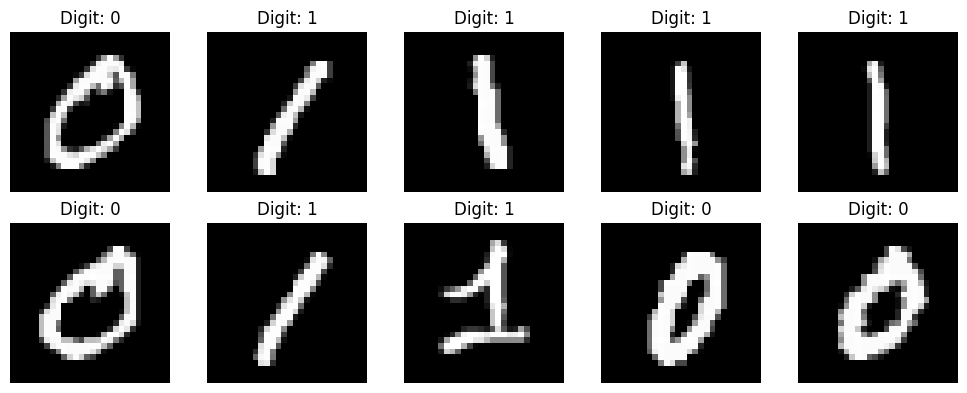

In [3]:

# Display some real MNIST images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image, label in zip(axes.ravel(), X_train[:10], y_train[:10]):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Digit: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()



## 3. Discriminative Model — Logistic Regression

Logistic Regression is used as the discriminative model.

The 28 × 28 image is flattened into 784 features. The model learns how pixel values relate to the class label (0 or 1), allowing it to learn a **decision boundary** between the two classes.


In [4]:

# Flatten 28x28 images into 784-dimensional vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# Train Logistic Regression
classifier = LogisticRegression(max_iter=1000)
classifier.fit(X_train_flat, y_train)

# Predict the test set
y_pred = classifier.predict(X_test_flat)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Discriminative Model Accuracy: {accuracy * 100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Digit 0", "Digit 1"]))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


Discriminative Model Accuracy: 99.95%

Classification Report:
              precision    recall  f1-score   support

     Digit 0       1.00      1.00      1.00       980
     Digit 1       1.00      1.00      1.00      1135

    accuracy                           1.00      2115
   macro avg       1.00      1.00      1.00      2115
weighted avg       1.00      1.00      1.00      2115

Confusion Matrix:
[[ 979    1]
 [   0 1135]]


## 4. Visual Comparison — Real Images and Discriminative Predictions

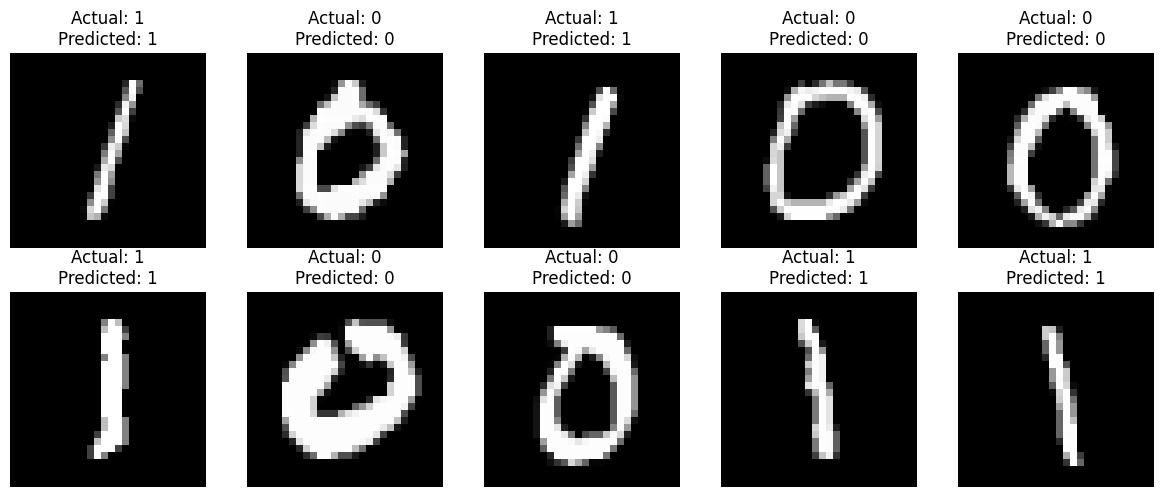

In [5]:

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for ax, image, actual, predicted in zip(
    axes.ravel(), X_test[:10], y_test[:10], y_pred[:10]
):
    ax.imshow(image, cmap="gray")
    ax.set_title(f"Actual: {actual}\nPredicted: {predicted}")
    ax.axis("off")

plt.tight_layout()
plt.show()



## 5. Generative Model — Simple Autoencoder

The Autoencoder receives an image and tries to reconstruct the same image.

It has two main parts:

1. **Encoder:** compresses the 784-pixel image into a smaller latent representation.
2. **Decoder:** reconstructs the image from that latent representation.

Unlike Logistic Regression, the Autoencoder is not trained using the digit labels as its target. Its objective is to learn the structure and visual patterns present in the input images.


In [6]:

# Build a simple Autoencoder
input_dim = 28 * 28
latent_dim = 32

encoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(latent_dim, activation="relu")
], name="encoder")

decoder = models.Sequential([
    layers.Input(shape=(latent_dim,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(input_dim, activation="sigmoid")
], name="decoder")

autoencoder_input = layers.Input(shape=(input_dim,))
encoded = encoder(autoencoder_input)
decoded = decoder(encoded)

autoencoder = models.Model(autoencoder_input, decoded, name="autoencoder")

autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder (Sequential)            │ (None, 32)             │       104,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Sequential)            │ (None, 784)            │       105,360 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 209,968 (820.19 KB)

 Trainable params: 209,968 (820.19 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:

# Train the Autoencoder
history = autoencoder.fit(
    X_train_flat,
    X_train_flat,
    epochs=10,
    batch_size=256,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.3781 - val_loss: 0.1875
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1647 - val_loss: 0.1441
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1368 - val_loss: 0.1293
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1248 - val_loss: 0.1184
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1152 - val_loss: 0.1103
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1079 - val_loss: 0.1043
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1022 - val_loss: 0.0993
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0972 - val_loss: 0.0951
Epoch 9/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0937 - val_loss: 0.0924
Epoch 10/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0911 - val_loss: 0.0900


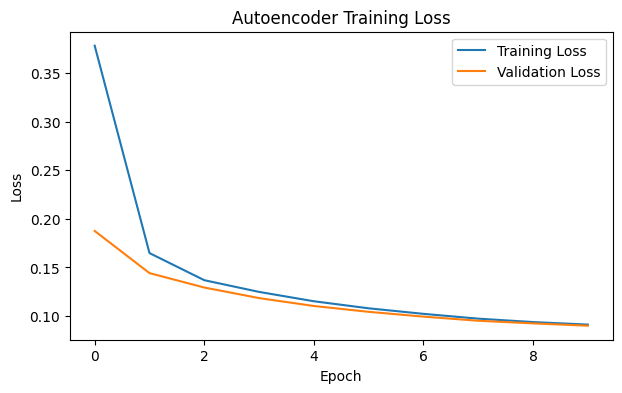

In [8]:

# Plot training and validation loss
plt.figure(figsize=(7, 4))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.show()


## 6. Real Images vs Autoencoder Reconstructions

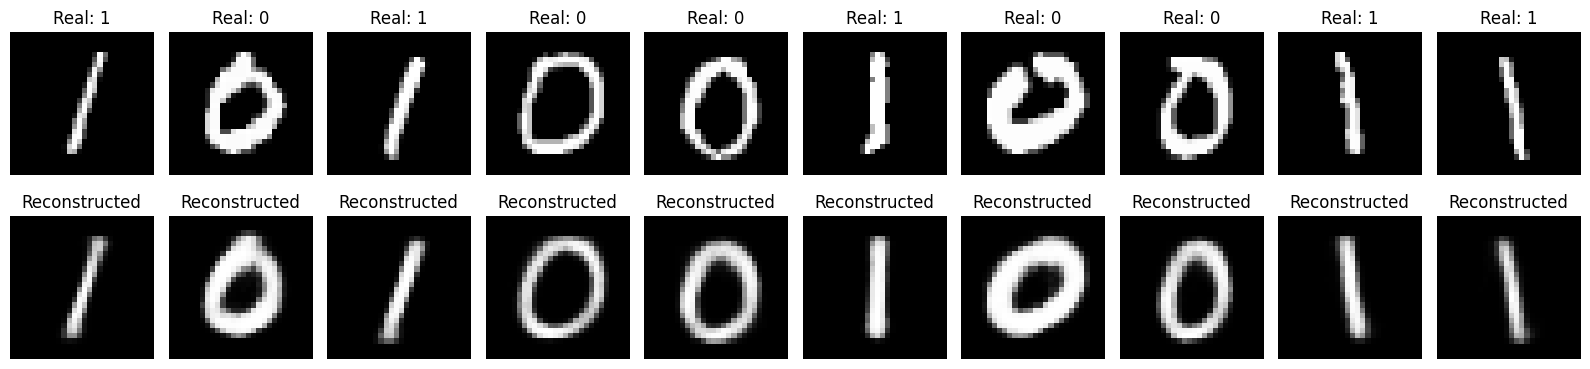

In [9]:

# Reconstruct test images
reconstructed = autoencoder.predict(X_test_flat[:10], verbose=0)

fig, axes = plt.subplots(2, 10, figsize=(16, 4))

for i in range(10):
    # Real image
    axes[0, i].imshow(X_test[i], cmap="gray")
    axes[0, i].set_title(f"Real: {y_test[i]}")
    axes[0, i].axis("off")

    # Reconstruction
    axes[1, i].imshow(reconstructed[i].reshape(28, 28), cmap="gray")
    axes[1, i].set_title("Reconstructed")
    axes[1, i].axis("off")

axes[0, 0].set_ylabel("Real", fontsize=12)
axes[1, 0].set_ylabel("Autoencoder", fontsize=12)

plt.tight_layout()
plt.show()



## 7. Generate New Digit-Like Images

A basic Autoencoder is primarily a reconstruction model rather than a fully probabilistic generative model. For this assignment, we can still demonstrate generation by taking latent representations learned from real 0/1 images and adding small random perturbations.

The decoder then converts these modified latent representations back into image space. The resulting images are **new digit-like samples**, although they are not as rigorously generative as samples from a Variational Autoencoder (VAE).


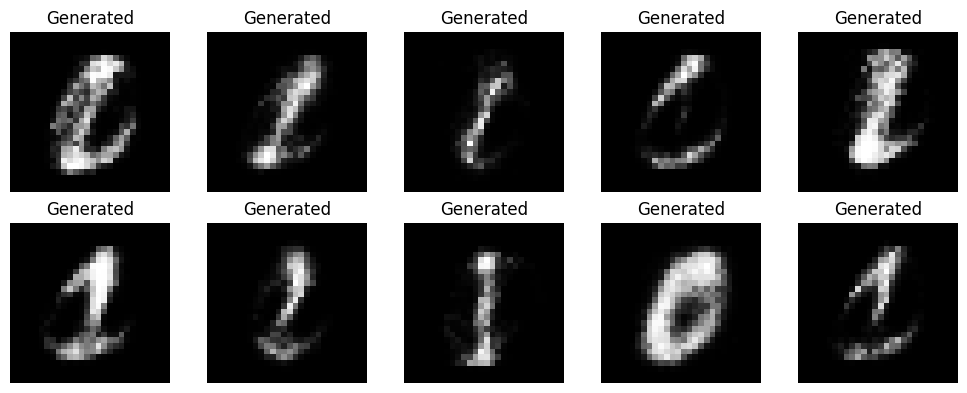

In [10]:

# Encode a collection of training images
latent_vectors = encoder.predict(X_train_flat[:5000], verbose=0)

# Estimate the latent distribution
latent_mean = latent_vectors.mean(axis=0)
latent_std = latent_vectors.std(axis=0)

# Generate new latent vectors by sampling around the learned latent space
rng = np.random.default_rng(42)
new_latent = rng.normal(
    loc=latent_mean,
    scale=latent_std * 0.8 + 1e-6,
    size=(10, latent_dim)
)

# Decode generated latent vectors into images
generated = decoder.predict(new_latent, verbose=0)

# Display generated images
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for ax, image in zip(axes.ravel(), generated):
    ax.imshow(image.reshape(28, 28), cmap="gray")
    ax.set_title("Generated")
    ax.axis("off")

plt.tight_layout()
plt.show()



## 8. Final Visual Comparison

This comparison shows the three main outcomes:

- **Real:** an original MNIST image.
- **Prediction:** the class predicted by the discriminative Logistic Regression model.
- **Generated:** a new digit-like image produced through the Autoencoder's learned latent representation.


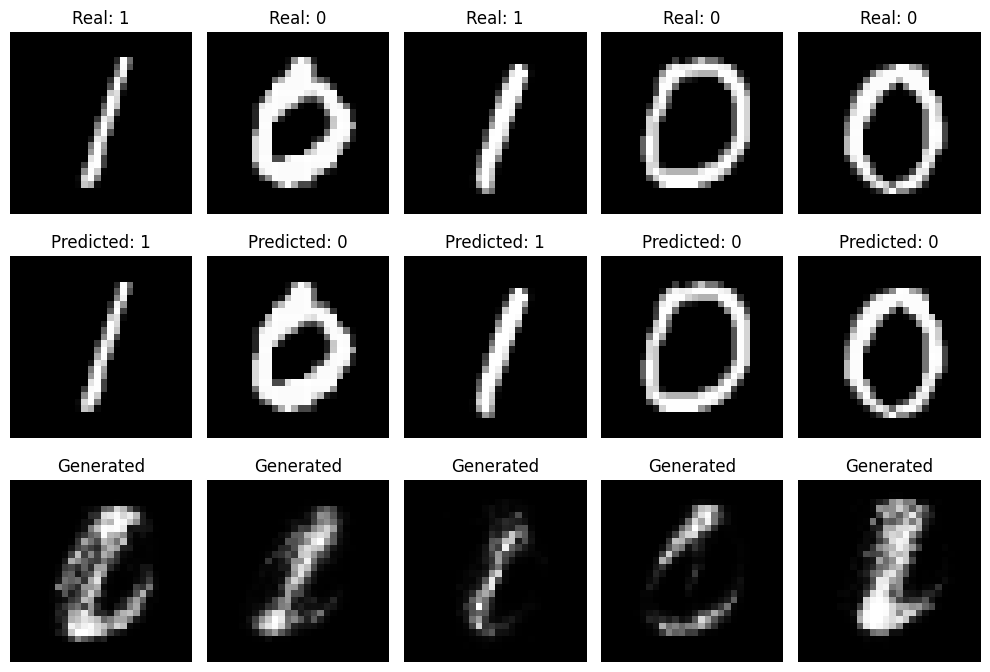

In [11]:

fig, axes = plt.subplots(3, 5, figsize=(10, 7))

# Real images
for i in range(5):
    axes[0, i].imshow(X_test[i], cmap="gray")
    axes[0, i].set_title(f"Real: {y_test[i]}")
    axes[0, i].axis("off")

# Discriminative predictions
for i in range(5):
    axes[1, i].imshow(X_test[i], cmap="gray")
    axes[1, i].set_title(f"Predicted: {y_pred[i]}")
    axes[1, i].axis("off")

# Generated images
for i in range(5):
    axes[2, i].imshow(generated[i].reshape(28, 28), cmap="gray")
    axes[2, i].set_title("Generated")
    axes[2, i].axis("off")

axes[0, 0].set_ylabel("REAL", fontsize=12)
axes[1, 0].set_ylabel("PREDICTION", fontsize=12)
axes[2, 0].set_ylabel("GENERATED", fontsize=12)

plt.tight_layout()
plt.show()



## 9. Written Reflection

The **discriminative model** learned patterns in the pixel values that help separate digit 0 from digit 1, so its main goal was to learn a decision boundary between the two classes. The **generative model** learned a compressed representation of the visual structure of the digits and used that representation to reconstruct and produce new digit-like images. The main difference is that the discriminative model focuses on predicting a class label, while the generative approach focuses on learning the structure of the input data. In simple terms, Logistic Regression learns **“which class does this image belong to?”**, while the Autoencoder learns **“what does this type of image look like?”**.



## 10. Conclusion

The experiment demonstrates the difference between **decision-boundary learning** and **data-distribution/representation learning**. Logistic Regression directly optimized classification performance for digits 0 and 1, while the Autoencoder learned to compress and reconstruct the visual information in those images. The discriminative model can therefore be evaluated mainly through classification accuracy, whereas the generative model is evaluated visually through the quality of its reconstructions and generated samples.
